## **Modelo Preditivo Baseado em *Machine Learning* para Identificação do Risco de Diabetes *Mellitus* Tipo 2**

**Aluna:** Tamires Alana Weber

---

######Este notebook contém o código utilizado no desenvolvimento do Trabalho de Conclusão de Curso intitulado: "Modelo Preditivo Baseado em *Machine Learning* para Identificação do Risco de Diabetes *Mellitus* Tipo 2". O objetivo é comparar diferentes algoritmos de aprendizado de máquina para predição do risco de DM2 utilizando o dataset *Diabetes Health Indicators*.
---

**1. Importação das Bibliotecas e Configurações Iniciais**

Nesta etapa, é realizada a importação das bibliotecas fundamentais para a manipulação de dados, visualização estatística e implementação dos algoritmos de *Machine Learning*.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, auc
import xgboost as xgb

from google.colab import drive
from google.colab import files

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


**2. Carregamento e Exploração dos Dados**

Nesta seção, o conjunto de dados é carregado para o ambiente de desenvolvimento. A exploração inicial é muito importante para entender a estrutura dos dados, identificar o tipo das variáveis e verificar a presença de valores ausentes ou inconsistentes que possam comprometer o treinamento dos modelos de *Machine Learning*.



*   Fonte de Dados: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

A base de dados utilizada foi obtida na plataforma *Kaggle*, sendo derivada do *Behavioral Risk Factor Surveillance System* (BRFSS) de 2015, disponibilizado pelo *Centers for Disease Control and Prevention* (CDC). O conjunto utilizado corresponde ao arquivo balanceado diabetes_binary_5050split_health_indicators_BRFSS2015.csv.

**2.1 Montagem do Google Drive**

Para garantir a persistência dos dados e facilitar o acesso aos arquivos do projeto, este notebook foi conectado ao Google Drive. Em seguida, o conjunto de dados é carregado em um DataFrame utilizando a biblioteca **Pandas**.

In [ ]:
drive.mount('/content/drive')

caminho = '/content/drive/MyDrive/TCC_Diabetes/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'

try:
    df = pd.read_csv(caminho)
    print("Dataset carregado com sucesso!")
    display(df.head()) # Mostra as 5 primeiras linhas
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}. Verifique se o caminho está correto.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset carregado com sucesso!


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


**2.2 Exploração Estatística e Estrutura dos Dados**

Nesta etapa, foi realizada uma inspeção no *dataset* para verificar as dimensões da base, o tipo de dado de cada coluna e se existem valores nulos.

In [ ]:
# Tamanho do dataset
print(f"O dataset possui {df.shape[0]} registros e {df.shape[1]} atributos.\n")

# Nomes das colunas e tipos de dados
print("--- Estrutura das Colunas ---")
df.info()

# Valores nulos
print("\n--- Valores Ausentes ---")
print(df.isnull().sum())

# Estatísticas descritivas básicas
print("\n--- Resumo Estatístico ---")
display(df.describe())

O dataset possui 70692 registros e 22 atributos.

--- Estrutura das Colunas ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  flo

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [ ]:
contagem_classes = df['Diabetes_binary'].value_counts()

print("Distribuição das classes antes da remoção de duplicados:")
print(contagem_classes)

Distribuição das classes antes da remoção de duplicados:
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


**2.3 Análise da Exploração**

A partir da análise exploratória inicial, foram observados alguns pontos importantes:


*   **Consistência do Dataset:** A base de dados apresenta 70.692 registros, um bom volume para garantir a generalização dos algoritmos. A análise também confirmou a ausência de valores nulos.
*   **Equilíbrio de Classes:** A variável alvo (*Diabetes_binary*) apresenta uma média de 0.5, confirmando que o *dataset* está balanceado entre casos positivos e negativos.


*  **Disparidade de Escalas:** Observou-se que variáveis como IMC possuem valores que variam de 12 a 98, enquanto a maioria das outras variáveis são binárias (0 ou 1). Essa disparidade pode exigir aplicação de técnicas como Normalização ou Padronização antes do treinamento dos modelos.





**2.4 Tradução dos Atributos**

Para assegurar a clareza na interpretação dos resultados foi realizada a tradução dos atributos do conjunto de dados para a língua portuguesa. Esta etapa de padronização, além de facilitar a elaboração de visualizações, garante que os modelos de *Machine Learning* operem sobre variáveis com nomenclaturas claras, o que é de suma importância para a documentação do projeto e para a futura análise de importância das variáveis no modelo final.

In [ ]:
dicionario_traducao = {
    'Diabetes_binary': 'Diabetes',
    'HighBP': 'Pressao_Alta',
    'HighChol': 'Colesterol_Alto',
    'CholCheck': 'Check_Colesterol',
    'BMI': 'IMC',
    'Smoker': 'Fumante',
    'Stroke': 'AVC',
    'HeartDiseaseorAttack': 'Doenca_Cardiaca',
    'PhysActivity': 'Atividade_Fisica',
    'Fruits': 'Frutas',
    'Veggies': 'Vegetais',
    'HvyAlcoholConsump': 'Consumo_Alcool_Pesado',
    'AnyHealthcare': 'Plano_Saude',
    'NoDocbcCost': 'Falta_Dinheiro_Medico',
    'GenHlth': 'Saude_Geral',
    'MentHlth': 'Saude_Mental',
    'PhysHlth': 'Saude_Fisica',
    'DiffWalk': 'Dificuldade_Caminhar',
    'Sex': 'Sexo',
    'Age': 'Idade',
    'Education': 'Escolaridade',
    'Income': 'Renda'
}

df.rename(columns=dicionario_traducao, inplace=True)

print("Nomes das colunas:")
print(df.columns.tolist())

Nomes das colunas:
['Diabetes', 'Pressao_Alta', 'Colesterol_Alto', 'Check_Colesterol', 'IMC', 'Fumante', 'AVC', 'Doenca_Cardiaca', 'Atividade_Fisica', 'Frutas', 'Vegetais', 'Consumo_Alcool_Pesado', 'Plano_Saude', 'Falta_Dinheiro_Medico', 'Saude_Geral', 'Saude_Mental', 'Saude_Fisica', 'Dificuldade_Caminhar', 'Sexo', 'Idade', 'Escolaridade', 'Renda']


**3. Pré-Processamento**

Esta fase é uma das mais importantes de todo o processo. O objetivo central é preparar o *dataset* para que os modelos consigam generalizar o conhecimento de forma eficiente.

**3.1 Limpeza de Registros Duplicados**

Para o treinamento de modelos preditivos, registros duplicados podem enviesar o aprendizado. Por isso, nesta etapa, estas entradas foram identificadas e removidas.

In [ ]:
total_duplicados = df.duplicated().sum()
print(f"Total de registros duplicados encontrados: {total_duplicados}")
tamanho_antes = len(df)

df = df.drop_duplicates()

tamanho_depois = len(df)

print(f"Registros removidos: {tamanho_antes - tamanho_depois}")
print(f"Dataset final: {tamanho_depois} registros únicos.")

Total de registros duplicados encontrados: 1635
Registros removidos: 1635
Dataset final: 69057 registros únicos.


Após a remoção dos registros, é importante reavaliar a distribuição da variável alvo.

Distribuição das classes após a limpeza:


,Quantidade,Percentual (%)
Diabetes,,
1.0,35097,50.823233
0.0,33960,49.176767


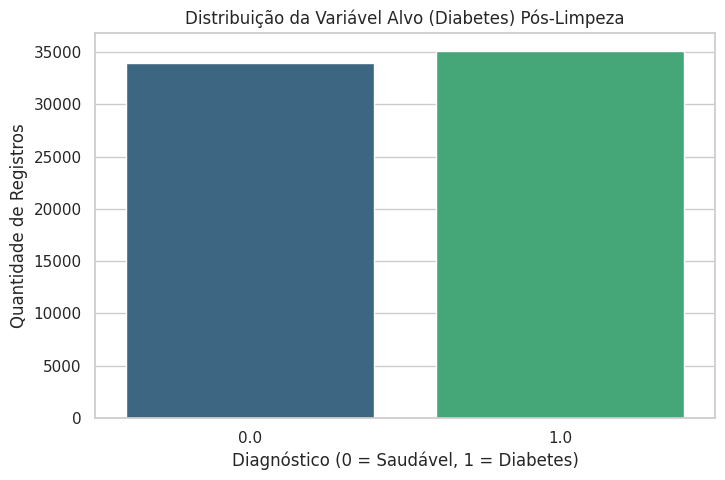

In [ ]:
print("Distribuição das classes após a limpeza:")
contagem = df['Diabetes'].value_counts()
proporcao = df['Diabetes'].value_counts(normalize=True) * 100

resumo_balanceamento = pd.DataFrame({
    'Quantidade': contagem,
    'Percentual (%)': proporcao
})

display(resumo_balanceamento)

plt.figure(figsize=(8, 5))
sns.countplot(x='Diabetes', data=df, palette='viridis', hue='Diabetes', legend=False)
plt.title('Distribuição da Variável Alvo (Diabetes) Pós-Limpeza')
plt.xlabel('Diagnóstico (0 = Saudável, 1 = Diabetes)')
plt.ylabel('Quantidade de Registros')
plt.show()

Mesmo após a exclusão, a variável alvo manteve uma distribuição equilibrada.

**3.2 Separar atibutos e variável alvo**

Nesta etapa, os dados foram divididos entre variáveis preditoras (X) e variável alvo (y). As variáveis preditoras correspondem aos atributos utilizados pelos algoritmos para realizar as previsões, enquanto a variável alvo representa a presença ou ausência de Diabetes *Mellitus* Tipo 2, que os modelos devem aprender a identificar.

In [ ]:
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

print("Variáveis preditoras:", X.shape)
print("Variável alvo:", y.shape)

Variáveis preditoras: (69057, 21)
Variável alvo: (69057,)


A separação dos dados confirmou que o conjunto possui 21 variáveis preditoras e 69.057 registros válidos após a etapa de limpeza.

**3.3 Separar em treino e teste**

Após a separação entre atributos e variável alvo, os dados foram divididos em conjuntos de treinamento e teste. O conjunto de treinamento, correspondente a 80% dos registros, foi utilizado para o treinamento dos modelos, enquanto os 20% restantes foram reservados para avaliação. A divisão foi realizada de forma estratificada, preservando a proporção das classes em ambos os conjuntos e garantindo uma avaliação mais representativa do desempenho dos algoritmos.

In [ ]:
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**4. Modelagem Preditiva**

Após a conclusão das etapas de pré-processamento, iniciou-se o treinamento dos modelos de aprendizado de máquina. Foram avaliados os algoritmos *Decision Tree*, *Random Forest*, *K-Nearest Neighbors* (KNN), *Support Vector Machine* (SVM) e XGBoost. Para cada modelo, foi realizado o ajuste de hiperparâmetros utilizando o GridSearchCV com validação cruzada estratificada de 5 folds. Em seguida, os melhores modelos foram avaliados no conjunto de teste por meio das métricas de acurácia, precisão, *recall*, *F1-score* e AUC-ROC.

***4.1 Random Forest***


In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

parametros_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=parametros_rf,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)
melhor_rf = grid_rf.best_estimator_

print("\n" + "="*40)
print("Melhores parâmetros:", grid_rf.best_params_)
print(f"Melhor AUC-ROC (CV - Treino): {grid_rf.best_score_:.4f}")
print("="*40)

y_prob_rf = melhor_rf.predict_proba(X_test)[:, 1]

y_pred_05 = (y_prob_rf >= 0.5).astype(int)

print("\n=== MÉTRICAS NO TESTE (THRESHOLD PADRÃO 0.5) ===")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_05):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_05):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_05):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_05):.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Melhores parâmetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Melhor AUC-ROC (CV - Treino): 0.8229

=== MÉTRICAS NO TESTE (THRESHOLD PADRÃO 0.5) ===
AUC-ROC:   0.8198
Accuracy:  0.7455
Precision: 0.7280
Recall:    0.7972
F1-score:  0.7610


**Ajuste de limiar - *Random Forest***

In [ ]:
y_proba_rf = melhor_rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)

youden_index = tpr - fpr
best_idx = np.argmax(youden_index)

best_threshold_rf = thresholds[best_idx]

print("Melhor limiar Random Forest:", best_threshold_rf)

y_pred_rf = (y_proba_rf >= best_threshold_rf).astype(int)

print("\n=== RANDOM FOREST COM LIMIAR AJUSTADO ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_rf))

Melhor limiar Random Forest: 0.47953590174297844

=== RANDOM FOREST COM LIMIAR AJUSTADO ===
Accuracy: 0.7476831740515494
Precision: 0.7216300940438871
Recall: 0.8198005698005698
F1-score: 0.7675891963987996
AUC-ROC: 0.8198257691300976


***4.2 Decision Tree***

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

parametros_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=parametros_dt,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)
melhor_dt = grid_dt.best_estimator_

print("\n" + "="*40)
print("Melhores parâmetros:", grid_dt.best_params_)
print(f"Melhor AUC-ROC (CV - Treino): {grid_dt.best_score_:.4f}")
print("="*40)

y_prob_dt = melhor_dt.predict_proba(X_test)[:, 1]

y_pred_dt_05 = (y_prob_dt >= 0.5).astype(int)

print("\n=== MÉTRICAS NO TESTE (THRESHOLD PADRÃO 0.5) ===")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_dt):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt_05):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt_05):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt_05):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_dt_05):.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Melhores parâmetros: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Melhor AUC-ROC (CV - Treino): 0.8011

=== MÉTRICAS NO TESTE (THRESHOLD PADRÃO 0.5) ===
AUC-ROC:   0.8035
Accuracy:  0.7331
Precision: 0.7131
Recall:    0.7946
F1-score:  0.7517


**Ajuste de limiar - *Decision Tree***

In [ ]:
y_prob_dt = melhor_dt.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)

youden_index = tpr - fpr
best_idx = youden_index.argmax()
best_threshold_dt = thresholds[best_idx]

print(f"Melhor limiar Decision Tree: {best_threshold_dt}")

y_pred_dt = (y_prob_dt >= best_threshold_dt).astype(int)

print("\n=== DECISION TREE COM LIMIAR AJUSTADO ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_dt):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_dt):.4f}")

Melhor limiar Decision Tree: 0.5384615384615384

=== DECISION TREE COM LIMIAR AJUSTADO ===
Accuracy:  0.7339
Precision: 0.7312
Recall:    0.7536
F1-score:  0.7422
AUC-ROC:   0.8035


**4.3 SVM**

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        probability=True,
        random_state=42
    ))
])

parametros_svm = {
    'svm__C': [0.01, 0.1, 1],
    'svm__kernel': ['rbf'],
    'svm__gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=parametros_svm,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Treinando o SVM...")
grid_svm.fit(X_train, y_train)

melhor_svm = grid_svm.best_estimator_

print("\n" + "="*40)
print("=== MELHORES PARÂMETROS SVM ===")
print(grid_svm.best_params_)
print(f"Melhor AUC-ROC (CV - Treino): {grid_svm.best_score_:.4f}")
print("="*40)

y_prob_svm = melhor_svm.predict_proba(X_test)[:, 1]

y_pred_svm_05 = (y_prob_svm >= 0.5).astype(int)

print("\n=== SVM: MÉTRICAS NO TESTE (THRESHOLD 0.5) ===")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_svm):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm_05):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_05):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm_05):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_svm_05):.4f}")

Treinando o SVM...
Fitting 5 folds for each of 6 candidates, totalling 30 fits


**Ajuste de limiar - SVM**

In [ ]:
y_prob_svm = melhor_svm.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)

youden_index = tpr - fpr
best_idx = youden_index.argmax()

best_threshold_svm = thresholds[best_idx]

print(f"Melhor limiar SVM: {best_threshold_svm}")

y_pred_svm = (y_prob_svm >= best_threshold_svm).astype(int)

print("\n=== SVM COM LIMIAR AJUSTADO ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_svm):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_svm):.4f}")

Melhor limiar SVM: 0.44618918837316246

=== SVM COM LIMIAR AJUSTADO ===
Accuracy:  0.7478
Precision: 0.7163
Recall:    0.8339
F1-score:  0.7707
AUC-ROC:   0.8164


**4.4 KNN**

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

parametros_knn = {
    'knn__n_neighbors': [3, 5, 11, 15, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=parametros_knn,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Treinando o KNN...")
grid_knn.fit(X_train, y_train)
melhor_knn = grid_knn.best_estimator_

print("\n" + "="*40)
print("=== MELHORES PARÂMETROS KNN ===")
print(grid_knn.best_params_)
print(f"Melhor AUC-ROC (CV - Treino): {grid_knn.best_score_:.4f}")
print("="*40)

y_prob_knn = melhor_knn.predict_proba(X_test)[:, 1]

y_pred_knn_05 = (y_prob_knn >= 0.5).astype(int)

print("\n=== KNN: MÉTRICAS NO TESTE (THRESHOLD 0.5) ===")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_knn):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn_05):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_05):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn_05):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_knn_05):.4f}")

Treinando o KNN...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== MELHORES PARÂMETROS KNN ===
{'knn__metric': 'manhattan', 'knn__n_neighbors': 21, 'knn__weights': 'uniform'}
Melhor AUC-ROC (CV - Treino): 0.8030

=== KNN: MÉTRICAS NO TESTE (THRESHOLD 0.5) ===
AUC-ROC:   0.8025
Accuracy:  0.7310
Precision: 0.7163
Recall:    0.7792
F1-score:  0.7465


**Ajuste de limiar - KNN**

In [ ]:
y_prob_knn = melhor_knn.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)

youden_index = tpr - fpr
best_idx = youden_index.argmax()
best_threshold_knn = thresholds[best_idx]

print(f"Melhor limiar KNN: {best_threshold_knn}")

y_pred_knn = (y_prob_knn >= best_threshold_knn).astype(int)

print("\n=== KNN COM LIMIAR AJUSTADO ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_knn):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_knn):.4f}")

Melhor limiar KNN: 0.47619047619047616

=== KNN COM LIMIAR AJUSTADO ===
Accuracy:  0.7333
Precision: 0.7020
Recall:    0.8259
F1-score:  0.7590
AUC-ROC:   0.8025


**4.5** ***XGBoost***

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

parametros_xgb = {
    'colsample_bytree': [0.8],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [100, 200],
    'subsample': [0.8]
}

xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=parametros_xgb,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Treinando o XGBoost...")
grid_xgb.fit(X_train, y_train)
melhor_xgb = grid_xgb.best_estimator_

print("\n" + "="*40)
print("=== MELHORES PARÂMETROS XGBOOST ===")
print(grid_xgb.best_params_)
print(f"Melhor AUC-ROC (CV - Treino): {grid_xgb.best_score_:.4f}")
print("="*40)

y_prob_xgb = melhor_xgb.predict_proba(X_test)[:, 1]

y_pred_xgb_05 = (y_prob_xgb >= 0.5).astype(int)

print("\n=== XGBOOST: MÉTRICAS NO TESTE (THRESHOLD 0.5) ===")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb_05):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_05):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb_05):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_xgb_05):.4f}")


Treinando o XGBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== MELHORES PARÂMETROS XGBOOST ===
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Melhor AUC-ROC (CV - Treino): 0.8266

=== XGBOOST: MÉTRICAS NO TESTE (THRESHOLD 0.5) ===
AUC-ROC:   0.8246
Accuracy:  0.7486
Precision: 0.7309
Recall:    0.7997
F1-score:  0.7638


**Ajuste de limiar -** ***XGBoost***

In [ ]:
y_prob_xgb = melhor_xgb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

youden_index = tpr - fpr
best_idx = youden_index.argmax()
best_threshold_xgb = thresholds[best_idx]

print(f"Melhor limiar XGBoost: {best_threshold_xgb}")

y_pred_xgb = (y_prob_xgb >= best_threshold_xgb).astype(int)

print("\n=== XGBOOST COM LIMIAR AJUSTADO ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")

Melhor limiar XGBoost: 0.4706443250179291

=== XGBOOST COM LIMIAR AJUSTADO ===
Accuracy:  0.7506
Precision: 0.7221
Recall:    0.8278
F1-score:  0.7714
AUC-ROC:   0.8246


**5. Importância das variáveis** - ***XGBoost***

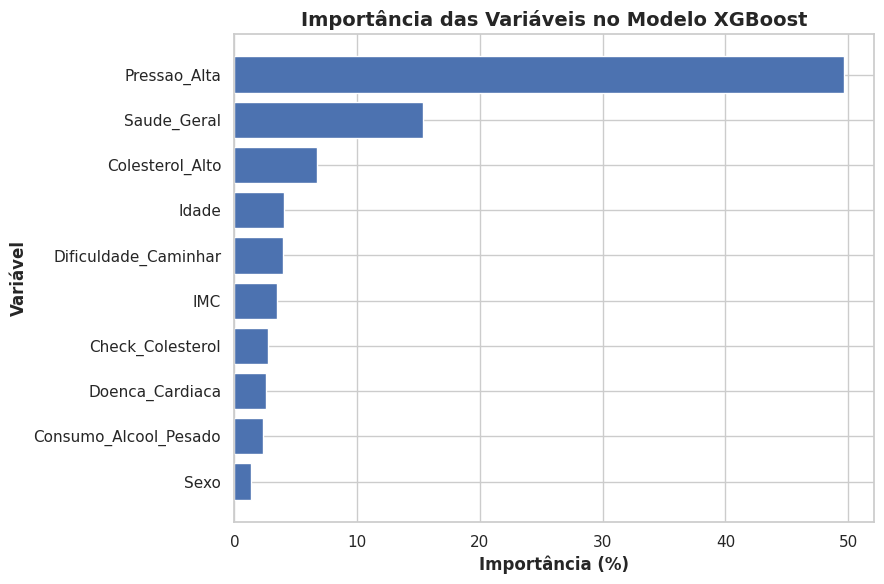

                 Variavel  Importancia (%)
0            Pressao_Alta        49.617943
13            Saude_Geral        15.372779
1         Colesterol_Alto         6.704059
18                  Idade         4.032387
16   Dificuldade_Caminhar         3.981407
3                     IMC         3.492195
2        Check_Colesterol         2.712477
6         Doenca_Cardiaca         2.539054
10  Consumo_Alcool_Pesado         2.306284
17                   Sexo         1.388477


In [ ]:

importancias = melhor_xgb.feature_importances_

features = X_train.columns

df_importancia = pd.DataFrame({
    'Variavel': features,
    'Importancia': importancias
})

df_importancia['Importancia (%)'] = df_importancia['Importancia'] * 100

df_importancia = df_importancia.sort_values(
    by='Importancia (%)',
    ascending=False
)

top10 = df_importancia.head(10)

plt.figure(figsize=(9, 6))

plt.barh(
    top10['Variavel'],
    top10['Importancia (%)']
)

plt.xlabel('Importância (%)', fontweight='bold')
plt.ylabel('Variável', fontweight='bold')
plt.title(
    'Importância das Variáveis no Modelo XGBoost',
    fontsize=14,
    fontweight='bold'
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print(top10[['Variavel', 'Importancia (%)']])